<a href="https://colab.research.google.com/github/aarsha-joshi/worldwideweb/blob/main/scripts/Llama_Prompting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Llama Training Pair Label Generation**

In [1]:
!pip install transformers==4.46.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 138.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 115.2 MB/s eta 0:00:00


In [2]:
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get('HF_token'))

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_id = "meta-llama/Meta-Llama-3-8B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

In [4]:
messages = [{"role": "user", "content": "Hello"}]

inputs = tokenizer.apply_chat_template(messages, return_tensors="pt").to("cuda")
outputs = model.generate(inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


user

Helloassistant

Hello! It's nice to meet you. Is there something I can help you with, or would you like to chat?


In [12]:
from google.colab import drive
drive.mount('/content/drive')

import os

# create the directory if it doesn't exist
os.makedirs("/content/worldwideweb/data/raw", exist_ok=True)

# copy the files
!cp "/content/drive/MyDrive/World Wide Web/cleaned_data/clean_train_live.jsonl" "/content/worldwideweb/data/raw/clean_train_live.jsonl"
!cp "/content/drive/MyDrive/World Wide Web/cleaned_data/clean_train_wa.jsonl" "/content/worldwideweb/data/raw/clean_train_wa.jsonl"

print("Done!")
!ls /content/worldwideweb/data/raw/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done!
clean_train_live.jsonl	clean_train_wa.jsonl


In [21]:
import os

os.chdir('/content')
!git clone https://token@github.com/aarsha-joshi/worldwideweb.git

# now move in
os.chdir('/content/worldwideweb')
!pip install -r requirements.txt

# verify
print(os.path.exists('data/dataset.py'))  # should print True

Cloning into 'worldwideweb'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 73 (delta 17), reused 71 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (73/73), 99.82 KiB | 228.00 KiB/s, done.
Resolving deltas: 100% (17/17), done.
True


In [25]:
import os

os.makedirs("data/raw", exist_ok=True)

# restore raw data from Drive
!cp "/content/drive/MyDrive/World Wide Web/cleaned_data/clean_train_live.jsonl" "/content/worldwideweb/data/raw/clean_train_live.jsonl"
!cp "/content/drive/MyDrive/World Wide Web/cleaned_data/clean_train_wa.jsonl" "/content/worldwideweb/data/raw/clean_train_wa.jsonl"

# restore labeled progress if it exists
labeled_drive_path = "/content/drive/MyDrive/World Wide Web/cleaned_data/wm_training_pairs_labeled.jsonl"
if os.path.exists(labeled_drive_path):
    !cp "{labeled_drive_path}" "/content/worldwideweb/data/raw/wm_training_pairs_labeled.jsonl"
    print("Restored labeled checkpoint")
else:
    print("No labeled checkpoint yet, starting fresh")

# verify files are there and check sizes
!ls -lh /content/worldwideweb/data/raw/

No labeled checkpoint yet, starting fresh
total 3.7G
-rw------- 1 root root 2.5G Apr 25 16:19 clean_train_live.jsonl
-rw------- 1 root root 1.3G Apr 25 16:19 clean_train_wa.jsonl
-rw-r--r-- 1 root root  262 Apr 25 16:18 print.py
-rw-r--r-- 1 root root 3.2K Apr 25 16:18 train.json1
-rw-r--r-- 1 root root 1.4K Apr 25 16:18 val.json1
-rw-r--r-- 1 root root    0 Apr 25 16:18 wm_training_pairs.json1
-rw-r--r-- 1 root root 4.3K Apr 25 16:18 wm_training_pairs.jsonl


True
Loading live dataset...
[Dataset] Loaded 5012 interactions from data/raw/clean_train_live.jsonl
Interactions loaded: 5012
Loading WA dataset...
[Dataset] Loaded 4218 interactions from data/raw/clean_train_wa.jsonl
Interactions loaded: 4218
Total interactions: 9230
Total training pairs: 91904
Sample pair keys: dict_keys(['pre_obs', 'action', 'post_obs', 'dom_changed'])
Sample pair: {'pre_obs': 'URL: https://www.wolframalpha.com/\nRootWebArea \'Wolfram|Alpha: Computational Intelligence\', focused, url=\'https://www.wolframalpha.com/\'\n\t[51] banner \'\', visible\n\t\t[52] navigation \'\', visible\n\t\t\t[53] list \'\', visible\n\t\t\t\t[54] listitem \'\', visible\n\t\t\t\t\t[55] button \'UPGRADE TO PRO\', clickable, visible, hasPopup=\'menu\', expanded=False\n\t\t\t\t\t\tStaticText \'UPGRADE TO PRO\'\n\t\t\t\t\t\t[57] image \'\', visible\n\t\t\t\t[58] listitem \'\', visible\n\t\t\t\t\t[59] button \'APPS\', clickable, visible, hasPopup=\'menu\', expanded=False\n\t\t\t\t\t\tStaticTex
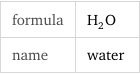
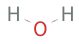
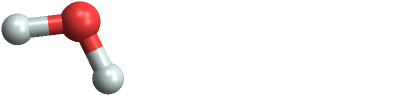

In [26]:
import sys
import os

# make sure we're in the right directory
os.chdir('/content/worldwideweb')

# add to path
sys.path.insert(0, '/content/worldwideweb')

# verify the data folder is there
print(os.path.exists('data/dataset.py'))  # should print True

import json
from data.dataset import NNetNavDataset
import sys
sys.path.insert(0, '/content/worldwideweb')

import json
import os
from data.dataset import NNetNavDataset


print("Loading live dataset...")
dataset_live = NNetNavDataset("data/raw/clean_train_live.jsonl")
print(f"Interactions loaded: {len(dataset_live.interactions)}")

print("Loading WA dataset...")
dataset_wa = NNetNavDataset("data/raw/clean_train_wa.jsonl")
print(f"Interactions loaded: {len(dataset_wa.interactions)}")

# combine all interactions
all_interactions = dataset_live.interactions + dataset_wa.interactions
print(f"Total interactions: {len(all_interactions)}")

# extract pairs from combined set
pairs = []
for interaction in all_interactions:
    for sc in interaction.state_changes:
        pairs.append(sc.to_wm_training_dict())

print(f"Total training pairs: {len(pairs)}")
print(f"Sample pair keys: {pairs[0].keys()}")
print(f"Sample pair: {pairs[0]}")

# filter out stop actions and unchanged states
def should_skip(pair):
    action = pair["action"].strip().lower()
    if action.startswith("stop"):
        return True
    if pair["pre_obs"] == pair["post_obs"]:
        return True
    return False

filtered_pairs = [p for p in pairs if not should_skip(p)]
print(f"After filtering stop/unchanged pairs: {len(filtered_pairs)}")

# sample down to a manageable size for Llama labeling
import random
random.seed(42)
sampled_pairs = random.sample(filtered_pairs, min(5000, len(filtered_pairs)))
print(f"Sampled {len(sampled_pairs)} pairs for labeling")

# save to jsonl
os.makedirs("data/raw", exist_ok=True)
with open("data/raw/wm_training_pairs.jsonl", "w") as f:
    for pair in sampled_pairs:
        f.write(json.dumps(pair) + "\n")

print("Saved to data/raw/wm_training_pairs.jsonl")

In [27]:
import os

# check drive is mounted
print("=== Drive contents ===")
!ls "/content/drive/MyDrive/World Wide Web/cleaned_data/"

# check if repo data folder exists
print("\n=== Repo data/raw folder ===")
!ls /content/worldwideweb/data/raw/

=== Drive contents ===
clean_train_live.jsonl	clean_train_wa.jsonl

=== Repo data/raw folder ===
clean_train_live.jsonl	train.json1		 wm_training_pairs.jsonl
clean_train_wa.jsonl	val.json1
print.py		wm_training_pairs.json1


In [28]:
def get_changed_lines(pre_obs, post_obs, context_lines=5):
    """Extract only the lines that differ between pre and post obs"""
    pre_lines = set(pre_obs.splitlines())
    post_lines = set(post_obs.splitlines())

    removed = [l for l in pre_lines if l not in post_lines and l.strip()]
    added = [l for l in post_lines if l not in pre_lines and l.strip()]

    return removed, added

def call_llama(pre_obs, action, post_obs):
    removed, added = get_changed_lines(pre_obs, post_obs)

    # if diff is small enough, send just the diff
    # if no diff found, fall back to truncated full trees
    if len(removed) + len(added) == 0:
        return "No structural changes detected."

    removed_text = "\n".join(removed[:50])  # cap at 50 lines
    added_text = "\n".join(added[:50])

    prompt = f"""You are analyzing changes in a web accessibility tree.

Action taken: {action}

Elements REMOVED from the tree:
{removed_text if removed_text else "none"}

Elements ADDED to the tree:
{added_text if added_text else "none"}

Based on these changes, describe in 2-3 sentences what structurally changed
in the accessibility tree. Be specific about element types and IDs."""

    messages = [{"role": "user", "content": prompt}]

    inputs = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    ).to("cuda")

    if inputs.shape[1] > 7000:
        return "SKIPPED: input too long"

    with torch.no_grad():
        outputs = model.generate(
            inputs,
            max_new_tokens=150,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    prompt_len = inputs.shape[1]
    new_tokens = outputs[0, prompt_len:]
    description = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    return description

# test on several pairs
for i in [0, 1, 5, 10, 20, 50]:
    test = sampled_pairs[i]
    removed, added = get_changed_lines(test["pre_obs"], test["post_obs"])
    print(f"\n=== Pair {i} ===")
    print(f"Action: {test['action']}")
    print(f"DOM changed flag: {test.get('dom_changed', 'unknown')}")
    print(f"Lines removed: {len(removed)}, Lines added: {len(added)}")
    result = call_llama(test["pre_obs"], test["action"], test["post_obs"])
    print(f"Output: {result}")
    print("-" * 50)


=== Pair 0 ===
Action: click [-1]
DOM changed flag: True
Lines removed: 4, Lines added: 5
Output: The accessibility tree has undergone a change where the heading element with ID [1562] 'Ask the Community' was initially removed, but then re-added. Additionally, an image element with ID [1452] 'overhead view looking into a skillet of Italian sausage, peppers and onions' was added, which was previously removed.
--------------------------------------------------

=== Pair 1 ===
Action: click [-1]
DOM changed flag: True
Lines removed: 361, Lines added: 483
Output: The accessibility tree has undergone significant changes, with several elements removed and new ones added. Specifically, a large number of links, images, and headings were removed, including elements with IDs such as [1208], [1053], [646], [951], [745], [1151], [848], [892], [1137], [1193], [1186], [631], [882], [748], [573], [1121], and [1158]. In contrast, new elements were added, including emphasis elements with IDs such as [

In [29]:
INPUT_PATH = "data/raw/wm_training_pairs.jsonl"
OUTPUT_PATH = "data/raw/wm_training_pairs_labeled.jsonl"

with open(INPUT_PATH, "r") as f:
    all_pairs = [json.loads(line) for line in f]

def get_processed_count():
    if not os.path.exists(OUTPUT_PATH):
        return 0
    with open(OUTPUT_PATH, "r") as f:
        return sum(1 for line in f if line.strip())

start_idx = get_processed_count()
print(f"Starting from index {start_idx} / {len(all_pairs)}")

with open(OUTPUT_PATH, "a") as out_f:
    for i in range(start_idx, len(all_pairs)):
        pair = all_pairs[i]

        try:
            description = call_llama(
                pair["pre_obs"],
                pair["action"],
                pair["post_obs"]
            )
            labeled = {
                "pre_obs": pair["pre_obs"],
                "action": pair["action"],
                "state_changes_description": description,
                "post_obs": pair["post_obs"]
            }
            out_f.write(json.dumps(labeled) + "\n")

        except Exception as e:
            print(f"Error on record {i}: {e}")
            labeled = {
                "pre_obs": pair["pre_obs"],
                "action": pair["action"],
                "state_changes_description": "",
                "post_obs": pair["post_obs"]
            }
            out_f.write(json.dumps(labeled) + "\n")

        if (i + 1) % 10 == 0:
            out_f.flush()
            print(f"Processed {i+1}/{len(all_pairs)}")

        if (i + 1) % 500 == 0:
            out_f.flush()
            # auto-save to Drive every 500 records
            os.system('cp /content/worldwideweb/data/raw/wm_training_pairs_labeled.jsonl "/content/drive/MyDrive/World Wide Web/cleaned_data/wm_training_pairs_labeled.jsonl"')
            print(f"--- Checkpoint saved to Drive at {i+1}/{len(all_pairs)} ---")

print("Done!")

Starting from index 0 / 5000
Processed 10/5000
Processed 20/5000
Processed 30/5000
Processed 40/5000
Processed 50/5000
Processed 60/5000
Processed 70/5000
Processed 80/5000
Processed 90/5000
Processed 100/5000
Processed 110/5000
Processed 120/5000
Processed 130/5000
Processed 140/5000
Processed 150/5000
Processed 160/5000
Processed 170/5000
Processed 180/5000
Processed 190/5000
Processed 200/5000
Processed 210/5000
Processed 220/5000
Processed 230/5000
Processed 240/5000
Processed 250/5000
Processed 260/5000
Processed 270/5000
Processed 280/5000
Processed 290/5000
Processed 300/5000
Processed 310/5000
Processed 320/5000
Processed 330/5000
Processed 340/5000
Processed 350/5000
Processed 360/5000
Processed 370/5000
Processed 380/5000
Processed 390/5000
Processed 400/5000
Processed 410/5000
Processed 420/5000
Processed 430/5000
Processed 440/5000
Processed 450/5000
Processed 460/5000
Processed 470/5000
Processed 480/5000
Processed 490/5000
Processed 500/5000
--- Checkpoint saved to Drive 

KeyboardInterrupt: 